# Imports

In [91]:
import math
import pprint
from enum import Enum

import drjit as dr
import mitsuba as mi
import matplotlib.pyplot as plt
import numpy as np

from util import create_and_get_output_path, write_data_json, write_render, write_figure, write_mirror

# Configuration

In [92]:
# Select the variant to use
# Print out to view which you have available
# Need to pick an AD variant for gradient descent
# LLVM for CPU, CUDA for GPU
# Double for double precision, nothing for single precision
# Each requires its own installations
# If you want double precision, you have to compile Mitsuba yourself: https://mitsuba.readthedocs.io/en/stable/src/developer_guide/compiling.html
# Make sure to invoke CMake with -DMI_ENABLE_EMBREE=0 and add the double variants to the mitsuba.conf
# Additionally, add build/Release/python folder to your PYTHONPATH and don't install mitsuba and drjit through pip
# You can confirm it's working by running print(mi.__file__) to confirm the directory
# print(mi.variants())
mitsuba_variant = 'cuda_ad_mono_double'
mi.set_variant(mitsuba_variant)

class TargetType(Enum):
    Flat = 0
    Cylindrical = 1

##############################################
# Configuration variables for the simulation #
##############################################
target_type = TargetType.Flat
I = 1
L = 1
f = L / 8
aperture = 1
half_aperture = aperture / 2
mirror1_num_segments = 1000
mirror1_spline_control_points = 5
mirror1_num_2d_vertices = mirror1_num_segments + 1
mirror1_start_x = -L
mirror1_end_x = -L
mirror1_start_y = -half_aperture
mirror1_end_y = half_aperture
mirror1_frozen_control_points_x = [mirror1_spline_control_points // 2]
mirror1_frozen_control_points_y = [0, mirror1_spline_control_points // 2, mirror1_spline_control_points - 1]
mirror1_opt_x_points = dr.linspace(mi.Float, mirror1_start_x, mirror1_end_x, mirror1_spline_control_points)
mirror1_opt_y_points = dr.linspace(mi.Float, mirror1_start_y, mirror1_end_y, mirror1_spline_control_points)
mirror1_should_split_curve = True

mirror2_num_segments = 1000
mirror2_spline_control_points = 5
mirror2_num_2d_vertices = mirror2_num_segments + 1
mirror2_start_x = f
mirror2_end_x = f
mirror2_start_y = 2 * f
mirror2_end_y = -2 * f
mirror2_frozen_control_points_x = [mirror2_spline_control_points // 2]
mirror2_frozen_control_points_y = [mirror2_spline_control_points // 2]
mirror2_opt_x_points = dr.linspace(mi.Float, mirror2_start_x, mirror2_end_x, mirror2_spline_control_points)
mirror2_opt_y_points = dr.linspace(mi.Float, mirror2_start_y, mirror2_end_y, mirror2_spline_control_points)
# mirror2_spline_angles = dr.linspace(mi.Float, 0, dr.pi, mirror2_spline_control_points)
# mirror2_opt_x_points = dr.sin(mirror2_spline_angles) * f
# mirror2_opt_y_points = dr.cos(mirror2_spline_angles) * f
mirror2_should_split_curve = True

use_custom_spawn_ray = True
custom_spawn_ray_offset = 1e-4
target_height = (aperture / mirror1_num_segments) * 10
target_half_height = target_height / 2
three_dimensional_thickness = target_half_height
optimization_iterations = 10000
optimization_rays = 10000
learning_rate = 0.0001
learning_rate_drop_factor = 0.1
learning_rate_drop_percentages = [0.5, 0.75, 0.9]
epsilon = 1e-6
mirror_rough_conductor_alpha = 0.005
test_mean_rays = 15
test_mean_ray_max_hits = 3
test_ray_max_length = 2
gradient_clipping_threshold = 0.75
gradient_clipping_norm_threshold = 1
gradient_clipping_drop_factor = 0.5
camera_res_x = 256
camera_res_y = 256
has_vertex_normals = True
spp=4000
ray_miss_penalty = 1000.0
light_dir = [-1, 0, 0]
ray_dir = mi.Vector3f(light_dir[0], light_dir[1], light_dir[2])
ray_start_pos = -0.5
ray_range_start = mirror1_start_y
ray_range_width = mirror1_end_y - mirror1_start_y
fermat_dist = 2 * L + 2 * f
beta_max_deg = 80
beta_max_rad = math.radians(beta_max_deg)
intersection_distance_loss_weight = 1
fermat_weight = 1e4
desired_angular_intensity_distribution_weight = 1e2
centre_distance_cutoff_point = target_height / 1000

match target_type:
    case TargetType.Flat:
        minification_constant_denom = 2.0 * math.sin(beta_max_rad)
        camera_x_pos = target_height
    case TargetType.Cylindrical:
        minification_constant_denom = 2.0 * beta_max_rad
        camera_x_pos = target_height * 2.0
    case _:
        raise Exception(f'Unhandled target type: {target_type}')

minification_constant = (aperture * I) / minification_constant_denom
camera_fov = math.degrees(math.atan(abs(camera_x_pos) / target_half_height))
camera_near_clip = abs(camera_x_pos) / 10
camera_far_clip = abs(camera_x_pos) + 0.1
##############################################
# Configuration variables for the simulation #
##############################################

# Check the configuration is valid
if mirror1_should_split_curve and mirror1_spline_control_points <= 3:
    raise Exception('Mirror 1 spline control points must be greater than 3 to allow for a curve split.')
if mirror2_should_split_curve and mirror2_spline_control_points <= 3:
    raise Exception('Mirror 2 spline control points must be greater than 3 to allow for a curve split.')

# Create an output directory to store info on the run
output_path = create_and_get_output_path('double_mirror_spline')

# Store the configuration
write_data_json({
    'simulation_id': output_path.name,
    'mitsuba_variant': mitsuba_variant,
    'target_type': target_type.name,
    'I': I,
    'L': L,
    'f': f,
    'aperture': aperture,
    'mirror1_num_segments': mirror1_num_segments,
    'mirror1_spline_control_points': mirror1_spline_control_points,
    'mirror1_start_x': mirror1_start_x,
    'mirror1_end_x': mirror1_end_x,
    'mirror1_start_y': mirror1_start_y,
    'mirror1_end_y': mirror1_end_y,
    'mirror1_frozen_control_points_x': mirror1_frozen_control_points_x,
    'mirror1_frozen_control_points_y': mirror1_frozen_control_points_y,
    'mirror1_opt_x_points': np.array(mirror1_opt_x_points, dtype=np.float64).tolist(),
    'mirror1_opt_y_points': np.array(mirror1_opt_y_points, dtype=np.float64).tolist(),
    'mirror1_should_split_curve': mirror1_should_split_curve,
    'mirror2_num_segments': mirror2_num_segments,
    'mirror2_spline_control_points': mirror2_spline_control_points,
    'mirror2_start_x': mirror2_start_x,
    'mirror2_end_x': mirror2_end_x,
    'mirror2_start_y': mirror2_start_y,
    'mirror2_end_y': mirror2_end_y,
    'mirror2_frozen_control_points_x': mirror2_frozen_control_points_x,
    'mirror2_frozen_control_points_y': mirror2_frozen_control_points_y,
    'mirror2_opt_x_points': np.array(mirror2_opt_x_points, dtype=np.float64).tolist(),
    'mirror2_opt_y_points': np.array(mirror2_opt_y_points, dtype=np.float64).tolist(),
    'mirror2_should_split_curve': mirror2_should_split_curve,
    'use_custom_spawn_ray': use_custom_spawn_ray,
    'custom_spawn_ray_offset': custom_spawn_ray_offset,
    'target_height': target_height,
    'three_dimensional_thickness': three_dimensional_thickness,
    'optimization_iterations': optimization_iterations,
    'optimization_rays': optimization_rays,
    'learning_rate': learning_rate,
    'learning_rate_drop_factor': learning_rate_drop_factor,
    'learning_rate_drop_percentages': learning_rate_drop_percentages,
    'epsilon': epsilon,
    'mirror_rough_conductor_alpha': mirror_rough_conductor_alpha,
    'test_mean_rays': test_mean_rays,
    'test_mean_ray_max_bounces': test_mean_ray_max_hits,
    'gradient_clipping_threshold': gradient_clipping_threshold,
    'gradient_clipping_norm_threshold': gradient_clipping_norm_threshold,
    'gradient_clipping_drop_factor': gradient_clipping_drop_factor,
    'camera_res_x': camera_res_x,
    'camera_res_y': camera_res_y,
    'camera_x_pos': camera_x_pos,
    'camera_fov': camera_fov,
    'camera_near_clip': camera_near_clip,
    'camera_far_clip': camera_far_clip,
    'has_vertex_normals': has_vertex_normals,
    'spp': spp,
    'ray_miss_penalty': ray_miss_penalty,
    'ray_dir': f"({light_dir[0]}, {light_dir[1]}, {light_dir[2]})",
    'ray_start_pos': ray_start_pos,
    'ray_range_start': ray_range_start,
    'ray_range_width': ray_range_width,
    'beta_max_deg': beta_max_deg,
    'minification_constant': minification_constant,
    'intersection_distance_loss_weight': intersection_distance_loss_weight,
    'fermat_weight': fermat_weight,
    'desired_angular_intensity_distribution_weight': desired_angular_intensity_distribution_weight,
    'centre_distance_cutoff_point': centre_distance_cutoff_point
}, output_path, 'config')

# Helpers

In [93]:
def get_ray_origins(ray_range):
    """
    Get the origins of rays to shoot. This will change depending on the direction of the rays.
    :return: The origins of the rays.
    """
    if abs(light_dir[0]) > epsilon:
        return mi.Point3f(ray_start_pos, ray_range, 0.0)
    else:
        return mi.Point3f(ray_range, ray_start_pos, 0.0)

def generate_rays(num_rays, should_random):
    """
    Generate rays for testing collisions.
    :param num_rays: The number of rays to generate.
    :param should_random: True if the rays should be randomly spread across the range, False if they should be linearly spaced.
    :return: The generated rays.
    """
    if should_random:
        ray_range = (ray_range_start + epsilon) + (ray_range_width - epsilon) * rng.random(mi.Float, num_rays)
    else:
        ray_range = dr.linspace(mi.Float, ray_range_start + epsilon, ray_range_start + ray_range_width - epsilon, num_rays)

    ray_origins = get_ray_origins(ray_range)
    return mi.Ray3f(o=ray_origins, d=ray_dir)

def generate_mirror_seed_info(num_2d_vertices, num_mirror_segments, start_x, end_x, start_y, end_y):
    """
    Generate the information needed to produce a mirror mesh.
    :param num_2d_vertices: The number of vertices in 2D for the mirror.
    :param num_mirror_segments: The number of segments for the mirror.
    :param start_x: The starting x coordinate.
    :param end_x: The ending x coordinate.
    :param start_y: The starting y coordinate.
    :param end_y: The ending y coordinate.
    :return: The mirror's vertices, faces, and number of vertices.
    """
    # Determine the vertices for the mirror's starting configuration which will just be a flat plane
    # Since we're in 3D, have 2 points per y, which is the reason for the doubling
    mirror_y_points = dr.linspace(mi.Float, start_y, end_y, num_2d_vertices)
    mirror_y_points = dr.repeat(mirror_y_points, 2)
    mirror_x_points = dr.linspace(mi.Float, start_x, end_x, num_2d_vertices)
    mirror_x_points = dr.repeat(mirror_x_points, 2)
    mirror_z_points = dr.tile(mi.Float(-three_dimensional_thickness, three_dimensional_thickness), num_2d_vertices)
    mirror_vertices = mi.Point3f(mirror_x_points, mirror_y_points, mirror_z_points)
    num_vertices = len(mirror_y_points)

    # Loop through and create 2 triangles per segment
    mirror_face_indices = []
    for mirror_segment_index in range(num_mirror_segments):
        i0 = 2 * mirror_segment_index                   # lower-left
        i1 = 2 * mirror_segment_index + 1               # lower-right
        i2 = 2 * (mirror_segment_index + 1)             # upper-left
        i3 = 2 * (mirror_segment_index + 1) + 1         # upper-right

        mirror_face_indices.append([i0, i2, i1])
        mirror_face_indices.append([i1, i2, i3])

    # Flatten out the faces, then reshape them into the expected mitsuba shape
    faces_flat = [index for tri in mirror_face_indices for index in tri]
    mirror_faces = dr.unravel(mi.Vector3u, mi.UInt32(faces_flat))

    # Return the info needed for later
    return mirror_vertices, mirror_faces, num_vertices

def create_mirror(mirror_name, num_mirror_segments, mirror_vertices, mirror_faces, num_vertices):
    """
    Create a mirror mesh and with the provided information.
    :param mirror_name: The name of the mesh.
    :param num_mirror_segments: The number of segments for the mirror.
    :param mirror_vertices: The vertices of the mirror.
    :param mirror_faces: The faces of the mirror.
    :param num_vertices: The number of vertices of the mirror.
    :return: The created mesh.
    """
    # Create the mirror mesh
    mirror_mesh = mi.Mesh(
        mirror_name,
        vertex_count=num_vertices,
        face_count=num_mirror_segments * 2,
        has_vertex_normals=has_vertex_normals,
        has_vertex_texcoords=False,
    )

    # Add the vertices and faces to the mesh
    mirror_mesh_params = mi.traverse(mirror_mesh)
    mirror_mesh_params['vertex_positions'] = dr.ravel(mirror_vertices)
    mirror_mesh_params['faces'] = dr.ravel(mirror_faces)

    # Apply the mesh changes and print info to confirm correct creation
    print(mirror_mesh_params.update())

    # Return the info needed for later
    return mirror_mesh

def prepare_mask(spline_control_points, frozen_control_points_x, frozen_control_points_y):
    """
    Set up the mask to freeze the control points for the mirror.
    :param spline_control_points: The number of spline control points.
    :param frozen_control_points_x: The indices of the control point x coordinates to freeze.
    :param frozen_control_points_y: The indices of the control point y coordinates to freeze.
    :return:
    """
    mirror_mask_x = dr.ones(mi.Float, spline_control_points)
    mirror_mask_y = dr.ones(mi.Float, spline_control_points)
    if frozen_control_points_x:
        dr.scatter(mirror_mask_x, 0.0, mi.UInt32(frozen_control_points_x))
    if frozen_control_points_y:
        dr.scatter(mirror_mask_y, 0.0, mi.UInt32(frozen_control_points_y))

    return mirror_mask_x, mirror_mask_y

def get_reflected_direction(direction, normal):
    """
    Get the perfect, specular reflection direction.
    :param direction: The incoming ray direction.
    :param normal: The normal of the surface.
    :return: The reflected direction.
    """
    return dr.normalize(direction - 2 * dr.dot(direction, normal) * normal)

def spawn_ray_wrapper(surface_interaction, direction):
    """
    A wrapper around the spawn_ray function as it seems to suffer from self-intersections despite the documentation stating that it will offset to avoid it.
    This issue seems especially prevalent when using double precision.
    :param surface_interaction: The surface interactions from which to start the rays.
    :param direction: The direction of the new rays to spawn.
    :return: The spawned rays.
    """
    if use_custom_spawn_ray:
        offset_si = mi.SurfaceInteraction3f(surface_interaction)
        offset_si.p += direction * custom_spawn_ray_offset
        return offset_si.spawn_ray(direction)
    else:
        return surface_interaction.spawn_rays(direction)

def is_valid_and_front(surface_interaction, used_rays):
    """
    Checks if the surface interaction is valid (did collide with something), and additionally checks that the collision was made with the correct side of the object.
    :param surface_interaction: The surface interaction in question.
    :param used_rays: The rays which were used to generate the surface interaction.
    :return: A validity mask which also considers the side.
    """
    current_hit_mask = surface_interaction.is_valid()
    current_dot = dr.dot(surface_interaction.sh_frame.n, used_rays.d)
    return current_hit_mask & (current_dot < 0)

# Mirror 1 Mesh

In [94]:
# Create the first mirror
mirror1_vertices, mirror1_faces, mirror1_num_vertices = generate_mirror_seed_info(mirror1_num_2d_vertices, mirror1_num_segments, mirror1_start_x, mirror1_end_x, mirror1_start_y, mirror1_end_y)
mirror1_mesh = create_mirror("mirror1", mirror1_num_segments, mirror1_vertices, mirror1_faces, mirror1_num_vertices)

[(Mesh[
  name = "mirror1",
  bbox = BoundingBox3d[
    min = [-1, -0.5, -0.005],
    max = [-1, 0.5, 0.005]
  ],
  vertex_count = 2002,
  vertices = [46.9 KiB of vertex data],
  face_count = 2000,
  faces = [23.4 KiB of face data],
  face_normals = 0,
  bsdf = SmoothDiffuse[
    reflectance = UniformSpectrum[value=[0.5]]
  ]
], {'vertex_positions', 'faces'})]


# Mirror 2 Mesh

In [95]:
# Create the second mirror
# This will be greatly modified by the splines, even prior to optimization, but this just gives it a mesh to work with
mirror2_vertices, mirror2_faces, mirror2_num_vertices = generate_mirror_seed_info(mirror2_num_2d_vertices, mirror2_num_segments, mirror2_start_x, mirror2_end_x, mirror2_start_y, mirror2_end_y)
mirror2_mesh = create_mirror("mirror2", mirror2_num_segments, mirror2_vertices, mirror2_faces, mirror2_num_vertices)

[(Mesh[
  name = "mirror2",
  bbox = BoundingBox3d[
    min = [0.125, -0.25, -0.005],
    max = [0.125, 0.25, 0.005]
  ],
  vertex_count = 2002,
  vertices = [46.9 KiB of vertex data],
  face_count = 2000,
  faces = [23.4 KiB of face data],
  face_normals = 0,
  bsdf = SmoothDiffuse[
    reflectance = UniformSpectrum[value=[0.5]]
  ]
], {'vertex_positions', 'faces'})]


# Cameras

In [96]:
# Create a camera to look at the target
# Heavily lifted from the docs: https://mitsuba.readthedocs.io/en/stable/src/inverse_rendering/caustics_optimization.html
target_camera = mi.load_dict({
    'type': 'perspective',
    'near_clip': camera_near_clip,
    'far_clip': camera_far_clip,
    'fov': camera_fov,
    'to_world': mi.ScalarTransform4f().look_at(
        target=[0, 0, 0],
        origin=[camera_x_pos, 0, 0],
        up=[0, 1, 0]
    ),
    'sampler': {
        'type': 'independent',
        'sample_count': 512  # Not really used
    },
    'film': {
        'type': 'hdrfilm',
        'width': camera_res_x,
        'height': camera_res_y,
        'pixel_format': 'luminance',
        'rfilter': {
            # Important: smooth reconstruction filter with a footprint larger than 1 pixel.
            # Use gaussian for a smoother result, but box for less blurring
            'type': 'gaussian'
        }
    },
})

# Create a camera to look at the whole scene
scene_camera = mi.load_dict({
    'type': 'perspective',
    'to_world': mi.ScalarTransform4f().look_at(
        origin=[-L + f, 0, aperture * 2], target=[-L + f, 0, 0], up=[0, 1, 0]
    ),
})

# Full Scene

In [97]:
# Create the scene
# Only the mirror2 are really required
# The light, integrator, and target aren't really used unless you want to render with mitsuba, but left for informational purposes
white_bsdf = mi.load_dict({
        'type': 'diffuse',
        'id': 'white-bsdf',
        'reflectance': { 'type': 'rgb', 'value': (1, 1, 1) },
})

match target_type:
    case TargetType.Flat:
        target = mi.load_dict({
            'type': 'rectangle',
            'id': 'target',
            'to_world': mi.ScalarTransform4f.translate([0, 0, 0]) @
                        mi.ScalarTransform4f.rotate([0, 1, 0], 90) @ # Rotate to face along X-axis
                        mi.ScalarTransform4f.scale([three_dimensional_thickness, target_half_height, 1]),
            'bsdf': white_bsdf,
        })
    case TargetType.Cylindrical:
        target = mi.load_dict({
            'type': 'cylinder',
            'id': 'target',
            'p0': [0, 0, -three_dimensional_thickness],
            'p1': [0, 0, three_dimensional_thickness],
            'radius': target_half_height,
            'bsdf': white_bsdf,
        })
    case _:
        raise Exception(f'Unhandled target type: {target_type}')

def create_base_scene():
    return {
        'type': 'scene',
        'integrator': {
            'type': 'ptracer',
            'samples_per_pass': spp,
            'max_depth': 8,
            'hide_emitters': True
        },
        'light': {
            'type': 'directional',
            'direction': light_dir,
            'irradiance': I
        }
    }

scene_dict = create_base_scene()
scene_dict['mirror1'] = mirror1_mesh
scene_dict['mirror2'] = mirror2_mesh
scene = mi.load_dict(scene_dict)

# Scene Parameters

In [98]:
# Get the scene information
scene_params = mi.traverse(scene)

# Display the scene information
# Not used here as we write custom tracing for a custom loss function, but this is where we can see which parameters we can optimize and are differentiable
print(scene_params)

SceneParameters[
  -----------------------------------------------------------------------------------------
  Name                                  Flags    Type              Parent
  -----------------------------------------------------------------------------------------
  allow_thread_reordering                        bool              Scene
  mirror1.bsdf.reflectance.value        ∂        Float64           UniformSpectrum
  mirror1.silhouette_sampling_weight             float             Mesh
  mirror1.faces                                  UInt              Mesh
  mirror1.vertex_positions              ∂, D     Float             Mesh
  mirror1.vertex_normals                ∂, D     Float             Mesh
  mirror1.vertex_texcoords              ∂        Float             Mesh
  mirror2.bsdf.reflectance.value        ∂        Float64           UniformSpectrum
  mirror2.silhouette_sampling_weight             float             Mesh
  mirror2.faces                                  UInt 

# Optimization

In [99]:
# Prepare the optimization
target_center = mi.Vector3f(0, 0, 0)
opt = mi.ad.Adam(lr=learning_rate)
opt['mirror1_control_points'] = mi.Vector2f(mirror1_opt_x_points, mirror1_opt_y_points)
opt['mirror2_control_points'] = mi.Vector2f(mirror2_opt_x_points, mirror2_opt_y_points)

# Prepare the constraints
mirror1_mask_x, mirror1_mask_y = prepare_mask(mirror1_spline_control_points, mirror1_frozen_control_points_x, mirror1_frozen_control_points_y)
mirror2_mask_x, mirror2_mask_y = prepare_mask(mirror2_spline_control_points, mirror2_frozen_control_points_x, mirror2_frozen_control_points_y)

# Prepare random number generation for stochastic rays
rng = dr.rng()

# Store data for later printing
losses = []
mean_intersection_distance_loss = None
mean_fermat_loss = None
mean_desired_angular_intensity_distribution_loss = None

def interpolate_bezier(num_vertices, num_control_points, index_offset, full_control_points):
    """
    Determine the vertex values for the interpolated Bézier curve to produce the mirror.
    :param num_vertices: Number of vertices in the curve.
    :param num_control_points: Number of control points in the curve.
    :param index_offset: The value, if any, by which to offset the index of the control points.
    :param full_control_points: The current control point values.
    :return: The interpolated x and y values of the vertices.
    """
    # Prepare the curve values
    curve_x = dr.zeros(mi.Float, num_vertices)
    curve_y = dr.zeros(mi.Float, num_vertices)

    # Determine the steps along the curve
    curve_t = dr.linspace(mi.Float, 0.0, 1.0, num_vertices)

    # Prepare other needed values
    spline_degree = num_control_points - 1

    # Actually evaluate the points
    for spline_control_point in range(num_control_points):
        # Calculate the binomial coefficient
        coeff = math.comb(spline_degree, spline_control_point)

        # Calculate the basis
        basis = coeff * dr.power(curve_t, spline_control_point) * dr.power(1 - curve_t, spline_degree - spline_control_point)

        # Add this control point's weighted contribution
        curve_x += dr.gather(mi.Float, full_control_points.x, spline_control_point + index_offset) * basis
        curve_y += dr.gather(mi.Float, full_control_points.y, spline_control_point + index_offset) * basis

    # Return the computed values
    return curve_x, curve_y

def update_mirror(mirror_name, should_split_curve, spline_control_points, num_2d_vertices):
    """
    Mold the mirror vertices into the shape of the spline based on the control points.
    This design uses a Bézier curve, optionally split into two halves to allow for pinning the midpoint.
    :param mirror_name: The name of the mirror.
    :param should_split_curve: True if the mirror should be split into 2 Bézier curves, False otherwise.
    :param spline_control_points: The number of control points in the curve.
    :param num_2d_vertices: The number of 2D vertices in the curve.
    """
    # Copy the values from the control points
    control_points = opt[f'{mirror_name}_control_points']

    if should_split_curve:
        # Calculate the sizes of the half splines
        spline_midpoint = spline_control_points // 2
        control_points_per_half = spline_midpoint + 1
        vertices_per_half = (num_2d_vertices // 2) + 1

        top_x, top_y = interpolate_bezier(vertices_per_half, control_points_per_half, 0, control_points)
        bot_x, bot_y = interpolate_bezier(vertices_per_half, control_points_per_half, spline_midpoint, control_points)

        # Concatenate while accounting for the repeated midpoint
        # Do so by skipping the last element of the top, and then using the full bottom
        curve_x = dr.concat([top_x[:-1], bot_x])
        curve_y = dr.concat([top_y[:-1], bot_y])
    else:
        curve_x, curve_y = interpolate_bezier(num_2d_vertices, spline_control_points, 0, control_points)

    # Double the vertices for thickness (Z-axis)
    new_x = dr.repeat(curve_x, 2)
    new_y = dr.repeat(curve_y, 2)
    new_z = dr.tile(mi.Float(-three_dimensional_thickness, three_dimensional_thickness), num_2d_vertices)

    # Reshape and modify the scene
    scene_params[f'{mirror_name}.vertex_positions'] = dr.ravel(mi.Point3f(new_x, new_y, new_z))

def update_scene():
    """
    Update the mirrors based on the spline control points.
    """
    # Update the mirrors
    update_mirror('mirror1', mirror1_should_split_curve, mirror1_spline_control_points, mirror1_num_2d_vertices)
    update_mirror('mirror2', mirror2_should_split_curve, mirror2_spline_control_points, mirror2_num_2d_vertices)

    # Propagate changes through the scene (e.g. rebuild BVH)
    scene_params.update()

def clip_gradients(mirror_name):
    """
    Clip the gradient to avoid super sudden jerks in any direction due to spatial noise.
    Two ideas here are glipping by value or clipping by norm.
    Clipping by value just sets a min and max value.
    Clipping by norm looks at the whole structure and chill it out.
    Both are provided for information.
    :param mirror_name: The name of the mirror.
    """
    # Clip by value
    grads = dr.grad(opt[f'{mirror_name}_control_points'])
    grads = dr.clip(grads, -gradient_clipping_threshold, gradient_clipping_threshold)
    # Clip by norm
    grads *= dr.minimum(1.0, gradient_clipping_norm_threshold / dr.norm(grads))

    # Update the gradients based on the modifications
    dr.set_grad(opt[f'{mirror_name}_control_points'], grads)

def pin_control_points(mirror_name, mask_x, mask_y, opt_x_points, opt_y_points):
    """
    Pin the provided control points to prevent them from moving.
    :param mirror_name: The name of the mirror.
    :param mask_x: The mask to select only the frozen control points in the x.
    :param mask_y: The mask to select only the frozen control points in the y.
    :param opt_x_points: The x values of the optimization control points.
    :param opt_y_points: The y values of the optimization control points.
    """
    optimizer_values = opt[f'{mirror_name}_control_points']
    optimizer_values.x = dr.select(mask_x == 0, opt_x_points, optimizer_values.x)
    optimizer_values.y = dr.select(mask_y == 0, opt_y_points, optimizer_values.y)
    opt[f'{mirror_name}_control_points'] = mi.Vector2f(optimizer_values.x, optimizer_values.y)

def get_optimizer_point(optimizer_values, index):
    """
    Get the control point as a mi.Point2f.
    Useful as you can't gather from a 2D array.
    :param optimizer_values: The values from which to draw the point.
    :param index: The index of the point.
    :return: An mi.Point2f wrapping the x and y at the index.
    """
    point_x = dr.gather(mi.Float, optimizer_values.x, index)
    point_y = dr.gather(mi.Float, optimizer_values.y, index)
    return mi.Point2f(point_x, point_y)

def smooth_mirror_centre(mirror_name, should_split_curve, spline_control_points):
    """
    Smooth out the mirror control points around the split point to prevent a cusp.
    :param mirror_name: The name of the mirror.
    :param should_split_curve: True if the mirror is split in two, false otherwise.
    :param spline_control_points: The control points for the spline.
    """
    # Only matters for split mirrors
    if not should_split_curve:
        return

    optimizer_values = opt[f'{mirror_name}_control_points']

    # Get the current values
    centre_index = spline_control_points // 2
    first_half_point = get_optimizer_point(optimizer_values, centre_index - 1)
    center_point = get_optimizer_point(optimizer_values, centre_index)
    second_half_point = get_optimizer_point(optimizer_values, centre_index + 1)

    # Get the tangent between the ends
    tangent = dr.normalize(first_half_point - second_half_point)

    # Re-centre along the tangent line
    first_half_dist = dr.norm(first_half_point - center_point)
    second_half_dist = dr.norm(second_half_point - center_point)
    first_half_new = center_point + tangent * first_half_dist
    second_half_new = center_point - tangent * second_half_dist

    # Create copies of the values and then scatter to set the appropriate, new values
    new_x = mi.Float(optimizer_values.x)
    new_y = mi.Float(optimizer_values.y)
    dr.scatter(new_x, first_half_new.x, centre_index - 1)
    dr.scatter(new_y, first_half_new.y, centre_index - 1)
    dr.scatter(new_x, second_half_new.x, centre_index + 1)
    dr.scatter(new_y, second_half_new.y, centre_index + 1)

    # Assign the modified values back
    opt[f'{mirror_name}_control_points'] = mi.Vector2f(new_x, new_y)

# The main optimization loop
# Run the update of the scene one time to make sure everything is loaded in correctly
update_scene()
int_learning_rate_drop_percentages = [int(p * optimization_iterations) for p in learning_rate_drop_percentages]
for i in range(optimization_iterations):
    # Reduce the learning rate if we are at certain iteration thresholds
    if int_learning_rate_drop_percentages and i >= int_learning_rate_drop_percentages[0]:
        int_learning_rate_drop_percentages.pop(0)
        opt.lr *= learning_rate_drop_factor
        gradient_clipping_threshold *= gradient_clipping_drop_factor
        gradient_clipping_norm_threshold *= gradient_clipping_drop_factor

    # Generate rays to use for the computation of loss
    # Rays are linearly-spaced across a broad area which will more than cover the first mirror
    # Alternatively, can randomly generate the origins so as not to fit to particular rays and to not allow the optimization to "get used to" the ray positions
    # Max is not differentiable, so we just overshoot to avoid DrJIT issues
    rays = generate_rays(optimization_rays, True)

    # Intersect with the first mirror
    si = scene.ray_intersect(rays)
    hit_mask = is_valid_and_front(si, rays)

    # Perform a perfect, specular reflection off of the first mirror to get the next ray
    wo = get_reflected_direction(rays.d, si.sh_frame.n)
    second_rays = spawn_ray_wrapper(si, wo)
    second_si = scene.ray_intersect(second_rays)
    second_hit_mask = is_valid_and_front(second_si, second_rays)

    # Move the rays to hit the second mirror
    # As a heuristic, figure out the middle point of the mirror's mouth and try to move the reflection in that direction
    mirror2_optimizer_values = opt[f'mirror2_control_points']
    mirror2_start_point = get_optimizer_point(mirror2_optimizer_values, 0)
    mirror2_end_point = get_optimizer_point(mirror2_optimizer_values, mirror2_spline_control_points - 1)
    mirror2_mouth_midpoint = mi.Point3f((mirror2_start_point.x + mirror2_end_point.x) / 2, (mirror2_start_point.y + mirror2_end_point.y) / 2, si.p.z)
    midpoint_direction = dr.normalize(mirror2_mouth_midpoint - si.p)
    midpoint_direction_loss = dr.square(1.0 - dr.dot(midpoint_direction, second_rays.d))

    # Perform the final reflection (hopefully) to the target
    # Using a combination of the angle and the distance as the loss
    # Taking the reflected ray and its perpendicular line going through the target to measure that distance as the loss
    third_ray_wo = get_reflected_direction(second_rays.d, second_si.sh_frame.n)
    line1_dir = mi.Vector2f(third_ray_wo.x, third_ray_wo.y)
    line2_dir = mi.Vector2f(third_ray_wo.y, -third_ray_wo.x)
    determinant = line1_dir.y * line2_dir.x - line1_dir.x * line2_dir.y
    determinant_t = line2_dir.y * second_si.p.x - line2_dir.x * second_si.p.y
    intersection_t = determinant_t / determinant
    hit_point = mi.Point2f(second_si.p.x, second_si.p.y)
    intersection = hit_point + intersection_t * line1_dir
    intersection_distance_loss = dr.norm(intersection)

    # Use Fermat's principle to maintain ray length
    # In order to allow for rays to start at an offset from the x=0 plane to avoid intersection with larger mirrors, rather than using a distance of start point to mirror hit, we just take the x value of the mirror hit
    # However, if off-axis, we would need to actually account for this and use a proper distance
    # first_ray_length = dr.norm(si.p - rays.o)
    first_ray_length = dr.abs(si.p.x)
    second_ray_length = dr.norm(second_si.p - si.p)
    third_ray_denom = dr.select(dr.abs(third_ray_wo.x) > epsilon, third_ray_wo.x, dr.sign(third_ray_wo.x) * epsilon)
    third_ray_t = (-second_si.p.x) / third_ray_denom
    third_ray_cross_points = second_si.p + third_ray_t * third_ray_wo
    third_ray_length = dr.abs(third_ray_t)
    total_ray_length = first_ray_length + second_ray_length + third_ray_length
    fermat_loss = dr.square(total_ray_length - fermat_dist)

    # Use the desired angular intensity distribution to figure out the $\beta$ angle we want
    # For a flat target, the desired distribution is $\cos(\beta)$
    # We also use $I(y) = 1$ for simplicity
    # So we have $dy = \cos(\beta) d\beta$
    # Integral to get $y = \sin(\beta) + C$
    # At y$=0$, the $\beta = 0$ so $C = 0$
    # So we get our loss with $y - \sin(\beta) = 0$
    # Square to get rid of signs
    # Add in the minification constant so we actually take into account the beta max
    desired_angular_intensity_distribution_loss = dr.square(rays.o.y - minification_constant * dr.sin(dr.atan2(second_si.p.y, second_si.p.x)))

    # If we are hitting both the mirrors, we initially want the distance to the centre as the loss, as everything falls apart if we aren't hitting the centre
    target_loss = intersection_distance_loss_weight * intersection_distance_loss

    # If we are hitting the centre (or close enough), we can then add in the other heuristics to refine
    # If we're not even hitting the centre, that is prioritized
    is_near_centre = (dr.abs(third_ray_cross_points.y) < centre_distance_cutoff_point) & hit_mask & second_hit_mask
    target_loss += dr.select(is_near_centre, fermat_weight * fermat_loss + desired_angular_intensity_distribution_weight * desired_angular_intensity_distribution_loss, 0.0)

    # Total the loss
    loss_val = dr.select(hit_mask, 0.0, ray_miss_penalty)
    loss_val = dr.select(hit_mask & ~second_hit_mask, (ray_miss_penalty / 2) * midpoint_direction_loss, loss_val)
    loss_val = dr.select(hit_mask & second_hit_mask, target_loss, loss_val)
    loss = dr.sum(loss_val) / optimization_rays

    # Perform the gradient descent
    losses.append(loss[0])
    mean_intersection_distance_loss = dr.mean(intersection_distance_loss)[0]
    mean_fermat_loss = dr.mean(fermat_loss)[0]
    mean_desired_angular_intensity_distribution_loss = dr.mean(desired_angular_intensity_distribution_loss)[0]
    dr.backward(loss)

    # Clip the gradients to prevent excessive movements
    clip_gradients('mirror1')
    clip_gradients('mirror2')

    # Take the step
    opt.step()

    # Avoid mitsuba getting confused while we manually mess with the control points
    dr.suspend_grad()

    # Pin the selected control points to prevent certain mirror points from moving
    pin_control_points('mirror1', mirror1_mask_x, mirror1_mask_y, mirror1_opt_x_points, mirror1_opt_y_points)
    pin_control_points('mirror2', mirror2_mask_x, mirror2_mask_y, mirror2_opt_x_points, mirror2_opt_y_points)

    # Smooth out the mirror centre to prevent a cusp
    smooth_mirror_centre('mirror1', mirror1_should_split_curve, mirror1_spline_control_points)
    smooth_mirror_centre('mirror2', mirror2_should_split_curve, mirror2_spline_control_points)

    # Go back to our regularly scheduled programming
    # Theoretically this should just be handled by a with block, but that wasn't re-enabling properly for some reason
    dr.resume_grad()

    # Get the latest scene version from the optimized values
    update_scene()

    # Log how we're doing in terms of loss
    print(f'Iteration {i + 1:10d}: loss={loss[0]:.20f}')

Iteration          1: loss=0.84515999145114728552
Iteration          2: loss=0.83385250317007086895
Iteration          3: loss=0.80854591212490711793
Iteration          4: loss=0.82071299077371806518
Iteration          5: loss=0.81149560601126891068
Iteration          6: loss=0.81125732364258462681
Iteration          7: loss=0.81618499200573513264
Iteration          8: loss=0.80719053664922790770
Iteration          9: loss=0.78191475347622918513
Iteration         10: loss=0.77756933928023719282
Iteration         11: loss=0.77271627211773485921
Iteration         12: loss=0.77525824163478873619
Iteration         13: loss=0.77284690289125368423
Iteration         14: loss=0.76113691943605987777
Iteration         15: loss=0.74536688823644881019
Iteration         16: loss=0.74890991740509216257
Iteration         17: loss=0.74576559488990901148
Iteration         18: loss=0.74688436635023103261
Iteration         19: loss=0.73220911884330497355
Iteration         20: loss=0.72869593925743292306


# Data Logging

In [100]:
results = {
    'final_mean_intersection_distance_loss': mean_intersection_distance_loss,
    'final_mean_fermat_loss': mean_fermat_loss,
    'final_mean_desired_angular_intensity_distribution_loss': mean_desired_angular_intensity_distribution_loss,
    'final_weighted_mean_intersection_distance_loss': intersection_distance_loss_weight * mean_intersection_distance_loss if mean_intersection_distance_loss else None,
    'final_weighted_mean_fermat_loss': fermat_weight * mean_fermat_loss if mean_fermat_loss else None,
    'final_weighted_mean_desired_angular_intensity_distribution_loss': desired_angular_intensity_distribution_weight * mean_desired_angular_intensity_distribution_loss if mean_intersection_distance_loss else None,
    'final_loss': losses[-1] if losses else None,
    'initial_loss': losses[0] if losses else None,
    'min_loss': min(losses) if losses else None,
    'max_loss': max(losses) if losses else None,
    'losses': losses
}

write_data_json(results, output_path, "results")
pprint.pp(results)

{'final_mean_intersection_distance_loss': 0.0004139850435225171,
 'final_mean_fermat_loss': 3.6415413204776937e-07,
 'final_mean_desired_angular_intensity_distribution_loss': 0.0003777914372479768,
 'final_weighted_mean_intersection_distance_loss': 0.0004139850435225171,
 'final_weighted_mean_fermat_loss': 0.0036415413204776937,
 'final_weighted_mean_desired_angular_intensity_distribution_loss': 0.03777914372479768,
 'final_loss': 0.0007075445731473427,
 'initial_loss': 0.8451599914511473,
 'min_loss': 0.00045302301362069066,
 'max_loss': 0.8451599914511473,
 'losses': [0.8451599914511473,
            0.8338525031700709,
            0.8085459121249071,
            0.8207129907737181,
            0.8114956060112689,
            0.8112573236425846,
            0.8161849920057351,
            0.8071905366492279,
            0.7819147534762292,
            0.7775693392802372,
            0.7727162721177349,
            0.7752582416347887,
            0.7728469028912537,
            0.76113

# Plot Loss

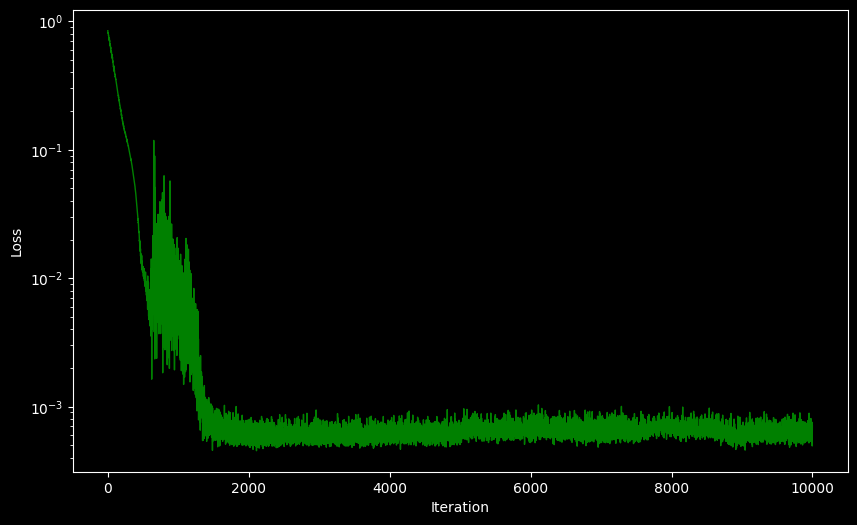

In [101]:
loss_fig = plt.figure(figsize=(10, 6))
plt.plot(losses, color='green', linewidth=1)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.yscale('log')
write_figure(loss_fig, output_path, 'loss')
plt.show()

# Final Mirror

In [102]:
# Extract the optimized data
mirror1_flat_vertices = scene_params['mirror1.vertex_positions']
mirror2_flat_vertices = scene_params['mirror2.vertex_positions']

# Get the actual values, where we only need half of them as we don't need both the points with the different z values
mirror1_points_2d = dr.unravel(mi.Point3f, mi.Float(mirror1_flat_vertices))
mirror1_final_x = np.array(mirror1_points_2d.x[::2])
mirror1_final_y = np.array(mirror1_points_2d.y[::2])
mirror2_points_2d = dr.unravel(mi.Point3f, mi.Float(mirror2_flat_vertices))
mirror2_final_x = np.array(mirror2_points_2d.x[::2])
mirror2_final_y = np.array(mirror2_points_2d.y[::2])

# Save the mirror data
write_mirror(mirror1_final_x, mirror1_final_y, output_path, 'mirror1')
write_mirror(mirror2_final_x, mirror2_final_y, output_path, 'mirror2')

# Mirror Plot

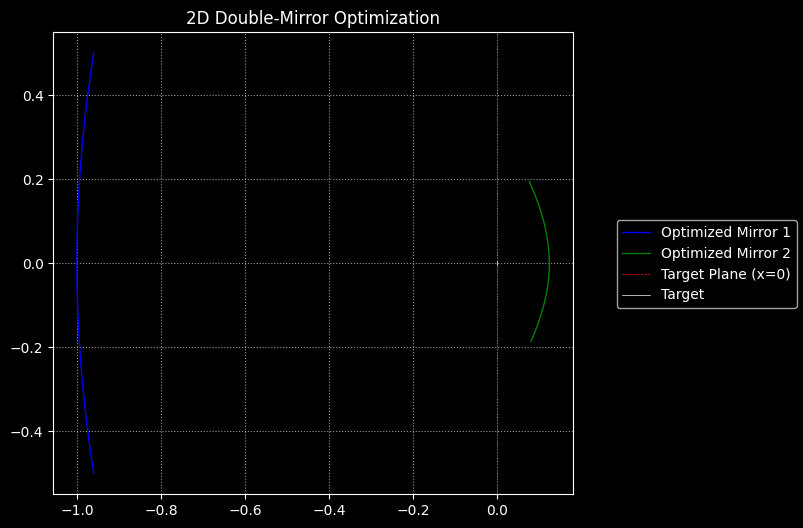

In [103]:
def create_base_mirror_plot(title, should_show_legend):
    """
    Create the base mirror plot, to which more details can be added.
    :param title: The title for the plot
    :param should_show_legend: True if a legend should be shown, false otherwise.
    :return: The created figure.
    """
    # Create the figure
    figure = plt.figure(figsize=(10, 6))
    ax = figure.add_subplot(1, 1, 1)

    # Draw the mirror by connecting the vertices
    plt.plot(mirror1_final_x, mirror1_final_y, 'b-', lw=1, label='Optimized Mirror 1')
    plt.plot(mirror2_final_x, mirror2_final_y, 'g-', lw=1, label='Optimized Mirror 2')

    # Draw the target plane and centre
    plt.axvline(x=0, color='red', linestyle='--', lw=0.5, label='Target Plane (x=0)')
    match target_type:
        case TargetType.Flat:
            plt.plot([0, 0], [target_half_height, -target_half_height], 'w-', lw=0.5, zorder=5, label='Target')
        case TargetType.Cylindrical:
            ax.add_patch(plt.Circle((0, 0), radius=target_half_height, color='w', zorder=5, label='Target'))
        case _:
            raise Exception(f'Unhandled target type: {target_type}')

    # Labels and formatting
    plt.title(title)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.gca().set_aspect('equal', adjustable='box')
    if should_show_legend:
        figure.legend(loc='outside right')

    # Return the figure for further modifications and writing
    return figure

# Create the figure
fig = create_base_mirror_plot('2D Double-Mirror Optimization', True)

# Save
write_figure(fig, output_path, 'optimized_mirrors')

# Display
plt.show()

# Mean Ray Test

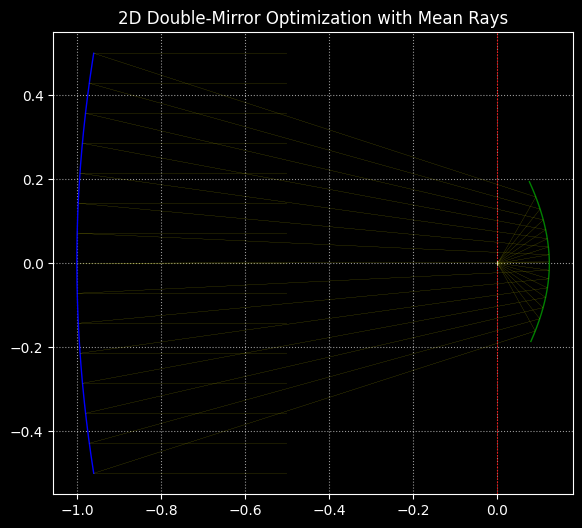

In [104]:
# Compute some mean rays
# Prepare the base case
# Broadcast as if all the values are the same, mitsuba just stores one but we need duplicates for the plotting
current_test_ray_mask = dr.full(mi.Int, 1, test_mean_rays)
test_rays = generate_rays(test_mean_rays, False)
test_x = [np.broadcast_to(np.array(test_rays.o.x), test_mean_rays)]
test_y = [np.broadcast_to(np.array(test_rays.o.y), test_mean_rays)]
current_test_rays = test_rays

# Iterate for every bounce desired
for test_ray_i in range(test_mean_ray_max_hits):
    # Determine the intersections with the scene
    test_si = scene.ray_intersect(current_test_rays)

    # Check the validity of the intersection
    test_hit_mask = test_si.is_valid() & current_test_ray_mask

    # Prepare special logic in the last iteration so that we can stop at the would-be target plane
    is_last_iteration = test_ray_i == test_mean_ray_max_hits - 1

    # For the last iteration, we want to stop at the x=0 plane as if there was a target there to see where it would cross
    # This is only if it doesn't collide with something or reach the max length first
    # For all other iterations, just go to the first collision or max length
    if is_last_iteration:
        test_denom = dr.select(dr.abs(current_test_rays.d.x) > epsilon, current_test_rays.d.x, dr.sign(current_test_rays.d.x) * epsilon)
        test_t = -current_test_rays.o.x / test_denom
        target_is_closer = (test_t > 0) & (test_t < test_si.t)  # Can't use python style simple comparisons as that causes issues with mitsuba with the multiple ray vectorization
        selected_t = dr.select(target_is_closer, test_t, dr.select(test_hit_mask, test_si.t, test_ray_max_length))
    else:
        selected_t = dr.select(test_hit_mask, test_si.t, test_ray_max_length)

    # Get the values to add for this intersection
    # Use the distance as defined above along the ray if this is a valid ray
    # If the ray was prematurely ended previously, just duplicate the point so that the parallelism can continue
    current_point_x = dr.select(current_test_ray_mask, current_test_rays.o.x + current_test_rays.d.x * selected_t, current_test_rays.o.x)
    current_point_y = dr.select(current_test_ray_mask, current_test_rays.o.y + current_test_rays.d.y * selected_t, current_test_rays.o.y)
    test_x.append(np.broadcast_to(np.array(current_point_x), test_mean_rays))
    test_y.append(np.broadcast_to(np.array(current_point_y), test_mean_rays))

    # Update the hit mask to see if we have any work left to do
    # Additionally check for back hits, and if so, we don't want to continue those rays
    current_test_ray_mask = test_hit_mask & is_valid_and_front(test_si, current_test_rays)
    if is_last_iteration or not dr.any(current_test_ray_mask > epsilon):
        break

    # Compute the bounce
    wo = get_reflected_direction(current_test_rays.d, test_si.sh_frame.n)
    current_test_rays = dr.select(current_test_ray_mask, spawn_ray_wrapper(test_si, wo), current_test_rays)

# Create the figure
fig = create_base_mirror_plot('2D Double-Mirror Optimization with Mean Rays', False)

# Plot the mean rays
paths_x = list(zip(*test_x))
paths_y = list(zip(*test_y))
for i in range(len(paths_x)):
    plt.plot(paths_x[i], paths_y[i], 'y-', lw=0.1, label='Mean Rays')

# Save
write_figure(fig, output_path, 'optimized_mirrors_with_mean_rays')

# Display
plt.show()

# Final Scene

In [105]:
mirror1_mesh.set_bsdf(white_bsdf)
mirror2_mesh.set_bsdf(white_bsdf)
final_scene_image = mi.render(scene, sensor=scene_camera, spp=spp)
final_scene_max_val = dr.max(final_scene_image)
final_scene_image = final_scene_image / final_scene_max_val
write_render(final_scene_image, output_path, "scene_render")
mi.util.convert_to_bitmap(final_scene_image)

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [768, 576],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 1.27 MiB of image data ]
]

# Optimized Mirror Meshes

In [106]:
# Search for the mirrors in the scene
mirror1_shape = None
mirror2_shape = None
for shape in scene.shapes():
    if "mirror1" in shape.id():
        mirror1_shape = shape
        continue
    if "mirror2" in shape.id():
        mirror2_shape = shape

# Create the mirror mesh from the optimized data in the scene
optimized_mirror1_mesh = create_mirror('optimized_mirror1', mirror1_num_segments, mirror1_shape.vertex_positions_buffer(), mirror1_shape.faces_buffer(), mirror1_num_vertices)
optimized_mirror2_mesh = create_mirror('optimized_mirror2', mirror2_num_segments, mirror2_shape.vertex_positions_buffer(), mirror2_shape.faces_buffer(), mirror2_num_vertices)

[(Mesh[
  name = "optimized_mirror1",
  bbox = BoundingBox3d[
    min = [-1, -0.5, -0.005],
    max = [-0.959854, 0.5, 0.005]
  ],
  vertex_count = 2002,
  vertices = [46.9 KiB of vertex data],
  face_count = 2000,
  faces = [23.4 KiB of face data],
  face_normals = 0,
  bsdf = SmoothDiffuse[
    reflectance = UniformSpectrum[value=[0.5]]
  ]
], {'vertex_positions', 'faces'})]
[(Mesh[
  name = "optimized_mirror2",
  bbox = BoundingBox3d[
    min = [0.07746, -0.186204, -0.005],
    max = [0.125004, 0.19417, 0.005]
  ],
  vertex_count = 2002,
  vertices = [46.9 KiB of vertex data],
  face_count = 2000,
  faces = [23.4 KiB of face data],
  face_normals = 0,
  bsdf = SmoothDiffuse[
    reflectance = UniformSpectrum[value=[0.5]]
  ]
], {'vertex_positions', 'faces'})]


# Full Scene with Target

In [107]:
final_scene_dict = create_base_scene()
final_scene_dict['optimized_mirror1'] = optimized_mirror1_mesh
final_scene_dict['optimized_mirror2'] = optimized_mirror2_mesh
final_scene_dict['target'] = target
final_scene = mi.load_dict(final_scene_dict)

# Final Target

In [108]:
# Make the mirror a true mirror
# This only matters if you want to render the scene with mitsuba, which isn't strictly necessary as we plot with matplotlib later, but leaving it in for interest
# The rough-conductor mirror is also provided for debugging, but with particle tracing we should be able to use an ideal mirror as we are forward rendering
ideal_mirror_bsdf = mi.load_dict({
    'type': 'conductor',
    'material': 'none'
})
mirror_bsdf = mi.load_dict({
    'type': 'roughconductor',
    'alpha': mirror_rough_conductor_alpha,
})
optimized_mirror1_mesh.set_bsdf(ideal_mirror_bsdf)
optimized_mirror2_mesh.set_bsdf(ideal_mirror_bsdf)

final_target_image = mi.render(final_scene, sensor=target_camera, spp=spp)
final_target_max_val = dr.max(final_target_image)
final_target_image = final_target_image / final_target_max_val
write_render(final_target_image, output_path, "target_render")
mi.util.convert_to_bitmap(final_target_image)

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [256, 256],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 192 KiB of image data ]
]